In [49]:
%run general_functions.ipynb

In [50]:
alk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/alkalinity_mask_y2035.nc')
mesh_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')

In [51]:
data = (alk_mask['alk_flux']+mesh_mask['tmask']).isel(t=0,z=0)

In [52]:
data = data.where((-40 < data.nav_lon) & (data.nav_lon < 30) & (30 < data.nav_lat) & (data.nav_lat < 90), drop=True)
data = data.where(data)

In [53]:
data

<xarray.DataArray (y: 197, x: 140)>
array([[ 1.,  1.,  1., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    nav_lon  (y, x) float64 -39.75 -39.25 -38.75 -38.25 ... 72.3 72.31 72.32
    nav_lat  (y, x) float64 30.03 30.03 30.03 30.03 ... 67.5 67.28 67.06 66.84
Dimensions without coordinates: y, x

In [54]:
d = '$^\circ$' 
lat_label = [f'35{d}N', f'50{d}N',f'65{d}N', f'70{d}N', f'85{d}N'] 
lon_label = [f'40{d}W', f'26{d}W', f'2{d}W',f'12{d}E', f'26{d}E']

In [55]:
# set north sea coordinates

In [57]:
polygon_coords = [(67, 88), (78, 96), (94, 72), (80, 55), (66,76)]

x = data['x'].values
y = data['y'].values
data = data.values

X, Y = np.meshgrid(x, y)
points = np.vstack((X.ravel(), Y.ravel())).T

poly_path = Path(polygon_coords)

ns = poly_path.contains_points(points).reshape(X.shape)
ns = ns * data
ns = ns.where(ns)
ns = ns.to_dataset(name='ns')

# mask_dd.to_netcdf('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/north_sea_polygon.nc')

AttributeError: 'numpy.ndarray' object has no attribute 'where'

In [40]:
ns

array([[ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

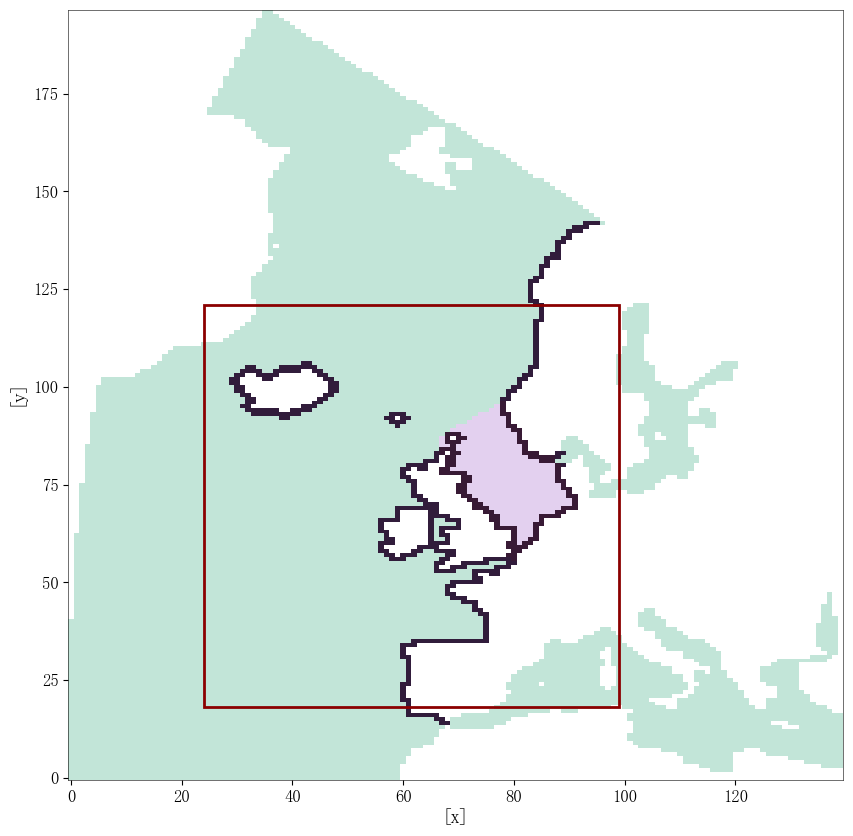

In [32]:
fig, ax = plt.subplots(
    figsize=(10, 10),
)

pcm = ax.pcolormesh(
    data.x, data.y, data,
    cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True),
    shading='auto',
)
rect = mpatches.Rectangle((24, 18), 75, 103, linewidth=2, edgecolor='darkred', facecolor='none')
rect = ax.add_patch(rect)

ns.ns.plot(cmap=sns.cubehelix_palette(start=.5, rot=-.1, as_cmap=True),add_colorbar=False)

ax.tick_params(
    axis='both',       # apply to both x and y axes
    which='both',      # major and minor ticks
    labelsize=12
)
ax.set_ylabel('[y]', fontsize=14)
ax.set_xlabel('[x]', fontsize=14)

for location in ['left','bottom', 'right', 'top']:
    ax.spines[location].set_linewidth(0.4)

pass

# plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/alkalinityAddition.png')